###### Ansible Playbooks

In [ ]:
We have seen how to run single tasks or one time tasks using Modules, 
but what if we need to execute multiple tasks? 

Playbooks help to run them in a scripted way.

Playbooks define variables, configurations, deployment steps, assign roles, perform multiple tasks.

For E.g. COPY / DELETE Files and Folders, install packages, start services. 

So primarily playbooks are defined to orchestrate the steps to multiple machines or servers
and get them all to a certain desired state.

Playbook is written in YAML format with a .yml file extension. 
One needs to be very careful with the format and alignment which makes it very sensitive.

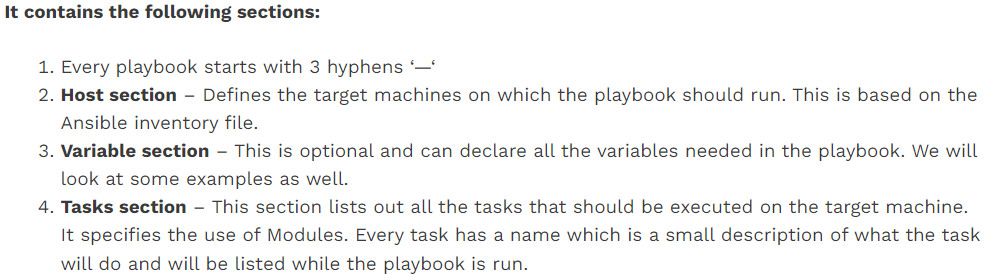

###### Ansible Playbook commands:- 

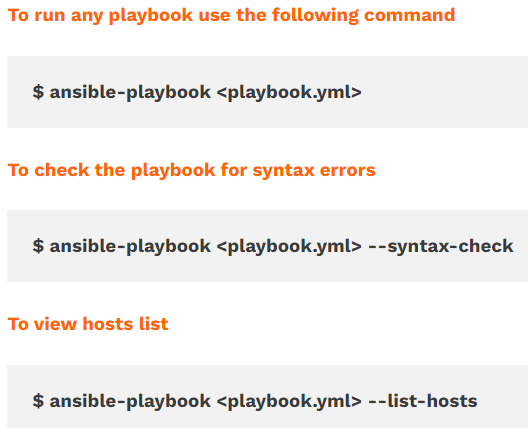

###### Example 1: Create the file on the target machines/nodes

In [ ]:
- hosts: webserver
  become: true
  tasks:
  - name: Create a file
    file: path=/home/ansadmin/devans.txt state=touch

# In the above example, we have used the file module to create the file.

###### Example 2: Create a directory with the mode as 775 and owner/group as Ansible.

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Create directory
    file: path=/home/ansadmin/devans state=directory mode=775 owner=ansadmin group=ansadmin

###### Example 3: Create multiple directories.

In [ ]:
To create multiple directories with one single task, we can use the loop with_items statement. 

So when we run the below playbook. it is interpreted as 3 different tasks.

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Create multiple directories
    file: path={{item}} state=directory
    with_items:
     - '/home/ansadmin/vn1'
     - '/home/ansadmin/vn2'
     - '/home/ansadmin/vn3'

###### Example 4: Create a user.

In [ ]:
# Let’s look at the user module to create and delete users in the playbook.

---
- hosts: webserver
  become: true
  tasks:
  - name: Create User
    user: name=devops1 password=admin groups=ansadmin shell=/bin/bash

###### Example 5: Remove user. 

In [ ]:
Removing a user is very easy and it will need the state to be set to absent. 
This is equivalent to the userdel command in Linux.

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Remove User
    user:
    name=devops1 state=absent remove=yes force=yes  

###### Example 6: Copy content to a file using the copy module.

In [ ]:
If we need to copy a file to the target machines or servers use the src and dest in the copy module.

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Copy content to file
    copy: content="Hello World devansible \n" dest=/home/ansadmin/devans.txt

###### Example 7: Replace all instances of a string.

In [ ]:
Using replace module we can replace a word with another word. 

The replace module will need 3 parameters i.e.
  - ‘path’, 
  - ‘regexp’ (to find the particular word) and 
  - ‘replace’ (providing another word for replacement).

In [ ]:
- hosts: webserver
  tasks:
  - name: Replace example
    replace:
     path: /home/ansadmin/devans.txt
     regexp: 'Hello'
     replace: "Devops"

###### Example 8: Archive or ZIP files and Folders

In [ ]:
Using the Ansible archive module, we can compress files or folders to ‘zip’, ‘.gz’, or ‘bz2’ format.

Note: 
 - The files or folders to be compressed should be available on the target servers and 
   should have the packages for tar, bzip2, gzip, zip file installed on them. 
   We can have a separate playbook task for installing these packages.

In [ ]:
---
- hosts: all
  become: true
  tasks:
  - name: Ansible zip file example
    archive:
     path: /home/ansadmin/devops1.txt
     dest: /home/ansadmin/devops2.zip
     format: zip
        
# The above playbook will zip the file devops1.txt to devops2.zip file

In [ ]:
---
- hosts: all
  become: true
  tasks:
  - name: Ansible zip multiple files example
    archive:
     path:
      - /home/ansadmin/devops1.txt
      - /home/ansadmin/devops2.txt
     dest: /home/ansadmin/devops_new.zip
     format: zip
        
# The above playbook will zip multiple files to devops_new.zip file.

###### Example 9: Working with date and timestamp

In [ ]:
Using the system date and timestamp helps in certain status or logging purposes. 
The Ansible facts provide access to remote or target servers date and time.
So we can use the debug module to print the output along with the var attribute as shown below.

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Date and Time Example in Ansible
    debug:
     var=ansible_date_time.date
    
# The above playbook displays the date.

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Date and Time Example in Ansible
    debug:
     var=ansible_date_time.time
    
# The above playbook displays the time.

In [ ]:
- hosts: all
  tasks:
  - name: Ansible timestamp filename example
    command: touch dev-ans{{ansible_date_time.date}}.log

# The above playbook will create a dynamic file based on the current date 
# for E.g. dev-ans2018-07-15.log

###### Example 10: Variables

In [ ]:
Variables are used to store values. 

In the below Example, we are declaring the variable 'n' with value devans. The output will be devans.

In [ ]:
- hosts: all
  vars:
   n1: devans
  tasks:
   - name: Ansible Basic Variable Example
     debug:
       msg: "{{ n1 }}"

In [ ]:
We can also have an array or a list of variables as in the below Example. [IGNORE]

In [ ]:
- hosts: all
  vars:
   n1:
    - Prince
    - Nisha
  tasks:
     - name: Ansible Array Example
       debug:
         msg: "{{ n1[1] }}"

# The indexing of the array starts from ZERO (0). Hence the output in the above example will be Nisha.

###### Example 11: Playbook to install vim editor and GIT on the target servers or machines.

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Install Package
    yum: name=vim,git state=latest

###### Example 12: Install Apache server. 

In [ ]:
---
- hosts: webserver
  become: true
  tasks:
  - name: Install Package
    yum: name=httpd state=present
  - name: Start httpd service
    service: name=httpd state=started

# Apart from the yum module, 
# the service module is also used to start the httpd service. 
# The tasks run from top to bottom synchronously.

In [ ]:
To check httpd server is running: - service httpd status

###### Example 13: Playbook to display client hostnames/ip addresses.

In [ ]:
---
 - hosts: all
   tasks:
   - name: hostname
     debug:
       var=ansible_hostname

###### Example 14: Playbook to install packages in client nodes. 

In [ ]:
---
- hosts: all
  become: yes
  name: "Install a List of Packages on Red Hat Based System"
  tasks:
    - name: "Installing a list of packages"
      yum:
        name:
          - curl
          - git
          - nano
          - htop

###### Example 15: Playbook to install system packages in client nodes using with_item loop.

In [ ]:
---
- hosts: all
  tasks:
    - name: Install Sysadmin Packages
      remote_user: ansadmin
      become: yes
      become_method: sudo
      yum: pkg={{ item }} state=installed update_cache=yes
      with_items:
               - vim
               - wget
               - curl
               - bash
               - ethtool
               - binutils
               - nfs-utils
               - pam
               - procps-ng
               - psmisc
               - smartmontools
               - unzip
               - sysstat


###### Example 16: Playbook to remove package

In [ ]:
- hosts: all
  tasks:
  - name: Removing a package from server
    yum:
      name=wget
      state=absent
    remote_user: ansadmin
    become: yes
    become_method: sudo
        
- to check wget version, use wget --version

###### Example 17: Print hostname, date and timezone, network information, os information, kernel version and Hardware information of hosts. 

In [ ]:
---
 - hosts: all
   tasks:
   - name: hostname
     debug:
       var=ansible_hostname

   - name: date and time
     vars:
      msg: |
       Date: {{ ansible_date_time.date }}
       Timezone: {{ ansible_date_time.tz }}
     debug:
      msg: "{{ msg.split('\n') }}"

   - name: network info
     vars:
      msg: |
       All Interface List: {{ ansible_interfaces }}
       All IP: {{ ansible_all_ipv4_addresses }}
       Gateway: {{ ansible_default_ipv4.gateway }}
       Eth0 MAC: {{ ansible_eth0.macaddress }}
     debug:
      msg: "{{ msg.split('\n') }}"

   - name: OS and Kernel info
     vars:
      msg: |
       Distribution: {{ ansible_distribution }}
       Release: {{ ansible_distribution_release }}
       Distribution Version: {{ ansible_distribution_version }}
       Kernel: {{ ansible_kernel }}
       Architecture: {{ ansible_architecture }}
     debug:
      msg: "{{ msg.split('\n') }}"

   - name: HW info
     vars:
      msg: |
       CPU: {{ ansible_processor }}
       CPU Core: {{ ansible_processor_cores }}
       RAM: {{ ansible_memtotal_mb }}
       SWAP: {{ ansible_memory_mb.swap.total }}
     debug:

      msg: "{{ msg.split('\n') }}"